# Tweets Dataset - Exploratory Data Analysis (EDA)

Exploratory analysis of the raw Twitter/X dataset across stock tickers.

**Data source**: `Raw_Data/tweets/` directory  
**Columns**: `ticker, search_date, body, post_date, replies, retweets, likes`  
**Period**: 10 October 2023 - 10 October 2025

## 1. Imports and Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Resolve data directory
BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "Raw_Data/tweets").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = BASE_DIR / "Raw_Data/tweets"
print(f"Data directory: {INPUT_DIR}")

# Load all tweet CSVs into a single DataFrame
all_files = sorted(INPUT_DIR.glob("tweets_*.csv"))
print(f"Found {len(all_files)} tweet CSV files")

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

tweets = pd.concat(dfs, ignore_index=True)
tweets["post_date"] = pd.to_datetime(tweets["post_date"], errors="coerce")
tweets["search_date"] = pd.to_datetime(tweets["search_date"], errors="coerce")
tweets["date_only"] = tweets["post_date"].dt.date

print(f"\nTotal tweets loaded: {len(tweets):,}")
tweets.head()

Data directory: C:\Users\alast\OneDrive - University of Greenwich\FYP\Raw_Data\tweets
Found 20 tweet CSV files

Total tweets loaded: 361,053


,ticker,search_date,body,post_date,replies,retweets,likes,date_only
0,AAPL,2023-10-10,Unusual Whales OI updates have been finished H...,2023-10-10 11:09:19+00:00,0,0,1.0,2023-10-10
1,AAPL,2023-10-10,"$WSM, $TER, $AAPL, $HDSN, $LRCX, $BSM, $MANH a...",2023-10-10 12:00:00+00:00,0,0,0.0,2023-10-10
2,AAPL,2023-10-10,$AAPL is moving higher,2023-10-10 12:38:13+00:00,0,0,0.0,2023-10-10
3,AAPL,2023-10-10,Key chip suppliers for iPhone 15 $AAPL $AVGO $...,2023-10-10 14:16:00+00:00,0,0,4.0,2023-10-10
4,AAPL,2023-10-10,Hard to catch $TSLA. In the picture you also s...,2023-10-10 14:52:44+00:00,0,0,0.0,2023-10-10


## 2. Dataset Overview

In [3]:
print("Shape:", tweets.shape)
print("\nColumn dtypes:")
print(tweets.dtypes)

print("\nMissing values:")
missing = tweets.isnull().sum()
missing_pct = (missing / len(tweets) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0])

print("\nDuplicate rows:", tweets.duplicated().sum())

Shape: (361053, 8)

Column dtypes:
ticker                      object
search_date         datetime64[ns]
body                        object
post_date      datetime64[ns, UTC]
replies                      int64
retweets                     int64
likes                      float64
date_only                   object
dtype: object

Missing values:


,Missing Count,Missing %



Duplicate rows: 0


In [4]:
tweets.describe(include="all")

,ticker,search_date,body,post_date,replies,retweets,likes,date_only
count,361053,361053,361053,361053,361053.000000,361053.000000,361053.000000,361053
unique,20,NaN,320241,NaN,NaN,NaN,NaN,732
top,TSLA,NaN,$TSLA,NaN,NaN,NaN,NaN,2024-04-04
freq,44855,NaN,823,NaN,NaN,NaN,NaN,787
mean,NaN,2024-10-10 13:03:57.535209216,NaN,2024-10-11 06:21:25.889587200+00:00,4.246432,5.421852,42.627351,NaN
min,NaN,2023-10-10 00:00:00,NaN,2023-10-10 00:05:56+00:00,0.000000,0.000000,0.000000,NaN
25%,NaN,2024-04-04 00:00:00,NaN,2024-04-04 20:29:14+00:00,0.000000,0.000000,0.000000,NaN
50%,NaN,2024-10-07 00:00:00,NaN,2024-10-07 20:00:15+00:00,0.000000,0.000000,3.000000,NaN
75%,NaN,2025-04-23 00:00:00,NaN,2025-04-23 14:23:49+00:00,2.000000,1.000000,12.000000,NaN
max,NaN,2025-10-10 00:00:00,NaN,2025-10-10 23:59:20+00:00,3600.000000,7200.000000,42000.000000,NaN


## 3. Tweet Counts by Ticker

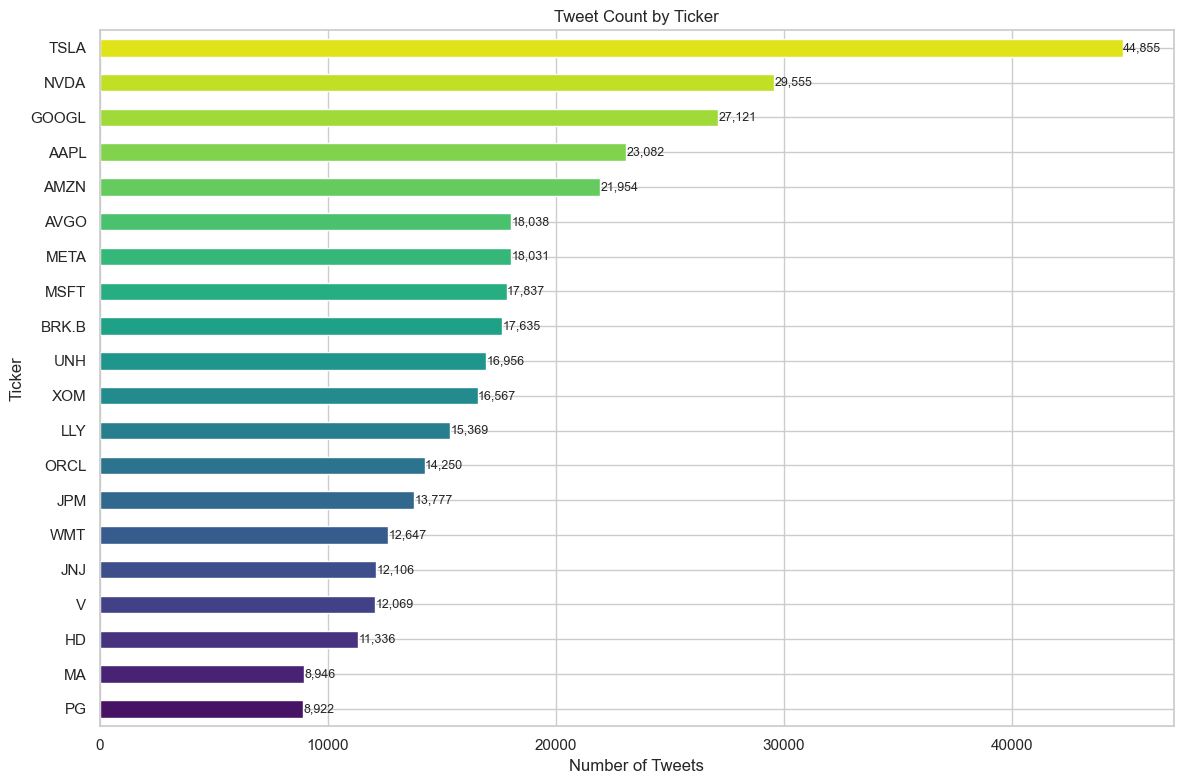


Mean: 18,053
Median: 16,762
Standard Deviation: 8,363


In [5]:
ticker_counts = tweets["ticker"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(ticker_counts)))
ax.set_xlabel("Number of Tweets")
ax.set_ylabel("Ticker")
ax.set_title("Tweet Count by Ticker")

for i, v in enumerate(ticker_counts):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nMean: {ticker_counts.mean():,.0f}")
print(f"Median: {ticker_counts.median():,.0f}")
print(f"Standard Deviation: {ticker_counts.std():,.0f}")

## 4. Date Range and Temporal Coverage

In [6]:
# Date range per ticker
date_ranges = tweets.groupby("ticker")["post_date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
date_ranges.columns = ["Earliest", "Latest", "Count"]
display(date_ranges)

,Earliest,Latest,Count
ticker,,,
TSLA,2023-10-10 17:05:39+00:00,2025-10-10 23:59:20+00:00,44855
NVDA,2023-10-10 02:12:27+00:00,2025-10-10 22:53:26+00:00,29555
GOOGL,2023-10-10 01:14:27+00:00,2025-10-10 20:08:16+00:00,27121
AAPL,2023-10-10 11:09:19+00:00,2025-10-10 23:57:31+00:00,23082
AMZN,2023-10-10 12:09:45+00:00,2025-10-10 23:23:19+00:00,21954
AVGO,2023-10-10 00:41:04+00:00,2025-10-10 21:46:23+00:00,18038
META,2023-10-10 11:12:40+00:00,2025-10-10 23:58:25+00:00,18031
MSFT,2023-10-10 12:56:21+00:00,2025-10-10 22:44:23+00:00,17837
BRK.B,2023-10-10 00:05:56+00:00,2025-10-10 19:16:57+00:00,17635


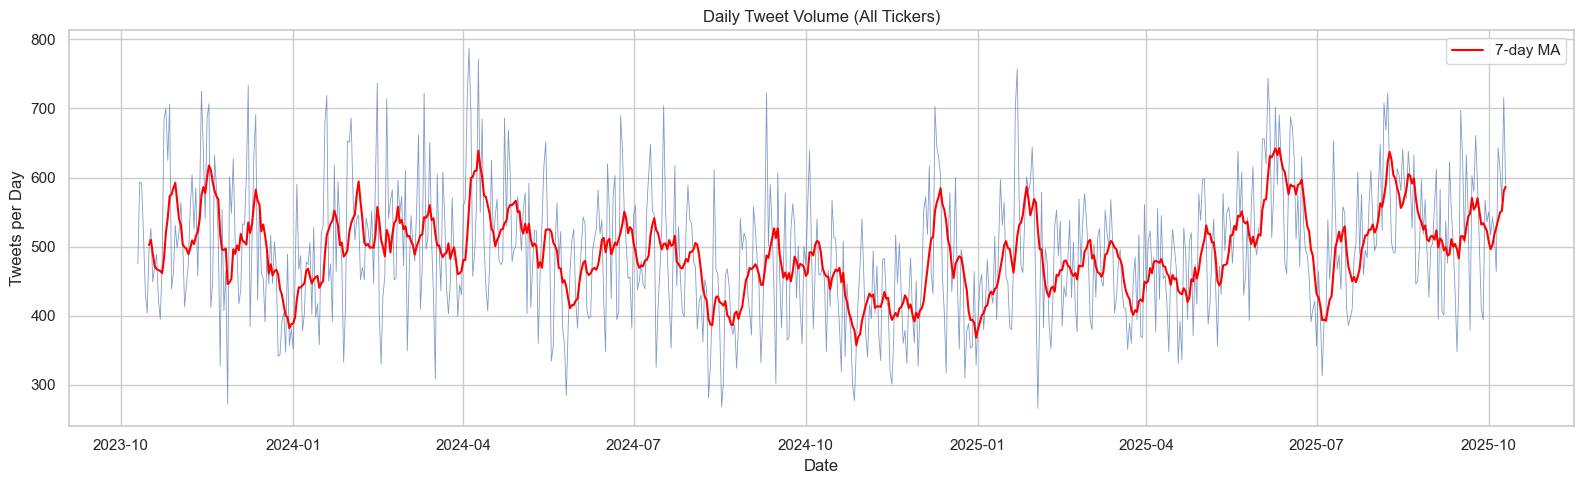

Average tweets per day: 493.2
Max tweets in a day: 787 (2024-04-04)
Min tweets in a day: 266 (2025-02-02)


In [7]:
# Daily tweet volume across all tickers
daily_counts = tweets.groupby("date_only").size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.6, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets per Day")
ax.set_title("Daily Tweet Volume (All Tickers)")

# Add 7-day rolling average
rolling = daily_counts.rolling(7).mean()
ax.plot(rolling.index, rolling.values, color="red", linewidth=1.5, label="7-day MA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average tweets per day: {daily_counts.mean():.1f}")
print(f"Max tweets in a day: {daily_counts.max()} ({daily_counts.idxmax()})")
print(f"Min tweets in a day: {daily_counts.min()} ({daily_counts.idxmin()})")

C:\Users\alast\AppData\Local\Temp\ipykernel_17360\1287609782.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["year_month"] = tweets["post_date"].dt.to_period("M")


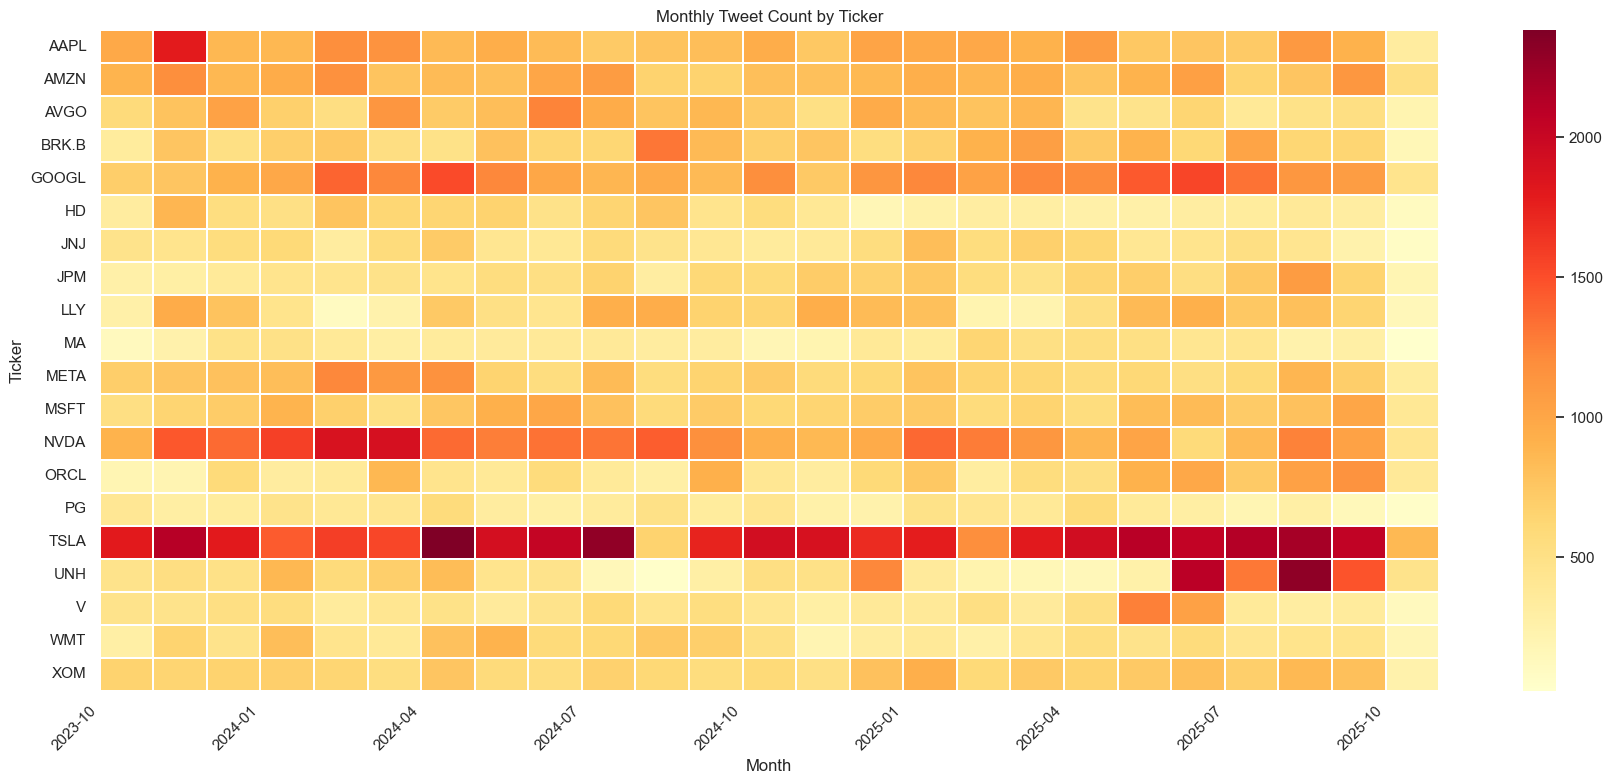

In [8]:
# Monthly tweet volume by ticker (heatmap)
tweets["year_month"] = tweets["post_date"].dt.to_period("M")
monthly_ticker = tweets.groupby(["year_month", "ticker"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(monthly_ticker.T, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Monthly Tweet Count by Ticker")
ax.set_xlabel("Month")
ax.set_ylabel("Ticker")

# Reduce x-tick clutter
tick_positions = range(0, len(monthly_ticker.index), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(monthly_ticker.index[i]) for i in tick_positions], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Engagement Metrics Analysis

In [9]:
# Engagement metrics summary
engagement_cols = ["replies", "retweets", "likes"]
engagement_stats = tweets[engagement_cols].describe()
display(engagement_stats)

# Total engagement
tweets["total_engagement"] = tweets["replies"] + tweets["retweets"] + tweets["likes"]
print(f"\nTotal engagement across all tweets: {tweets['total_engagement'].sum():,}")
print(f"Average engagement per tweet: {tweets['total_engagement'].mean():.1f}")

,replies,retweets,likes
count,361053.000000,361053.000000,361053.000000
mean,4.246432,5.421852,42.627351
std,24.899027,54.064705,324.338049
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,3.000000
75%,2.000000,1.000000,12.000000
max,3600.000000,7200.000000,42000.000000



Total engagement across all tweets: 18,881,496.0
Average engagement per tweet: 52.3


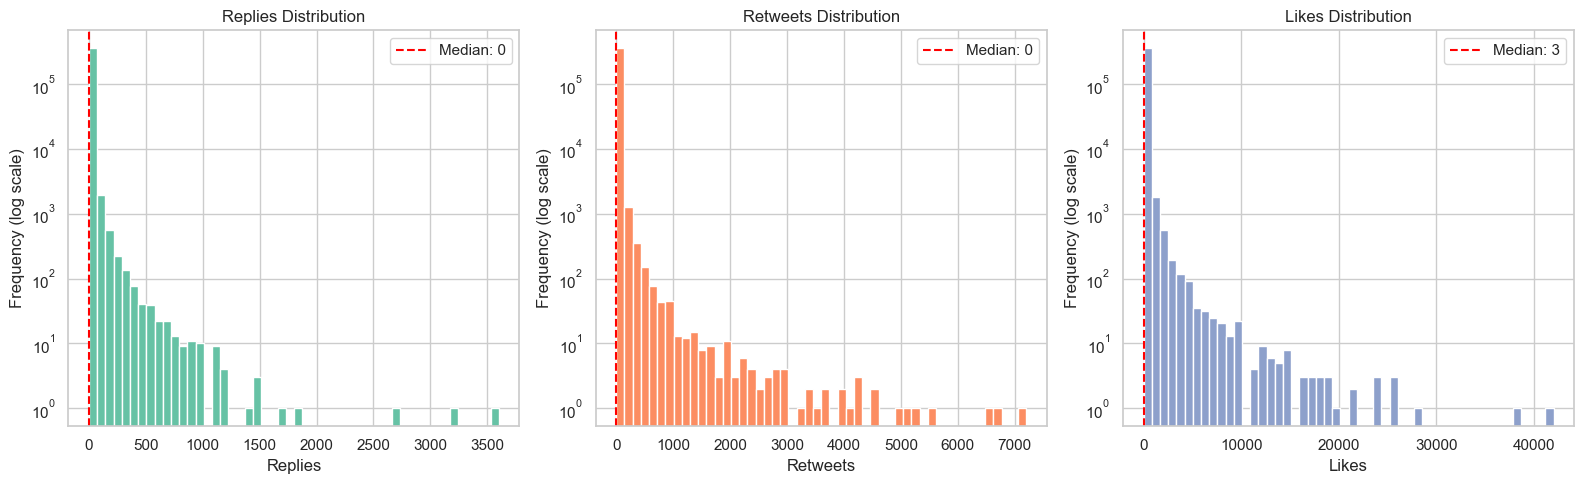

In [10]:
# Distribution of engagement metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(engagement_cols):
    # Use log scale for better visualization (add 1 to handle zeros)
    data = tweets[col] + 1
    axes[i].hist(data, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", log=True)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Frequency (log scale)")
    axes[i].set_title(f"{col.capitalize()} Distribution")
    axes[i].axvline(tweets[col].median() + 1, color="red", linestyle="--", label=f"Median: {tweets[col].median():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

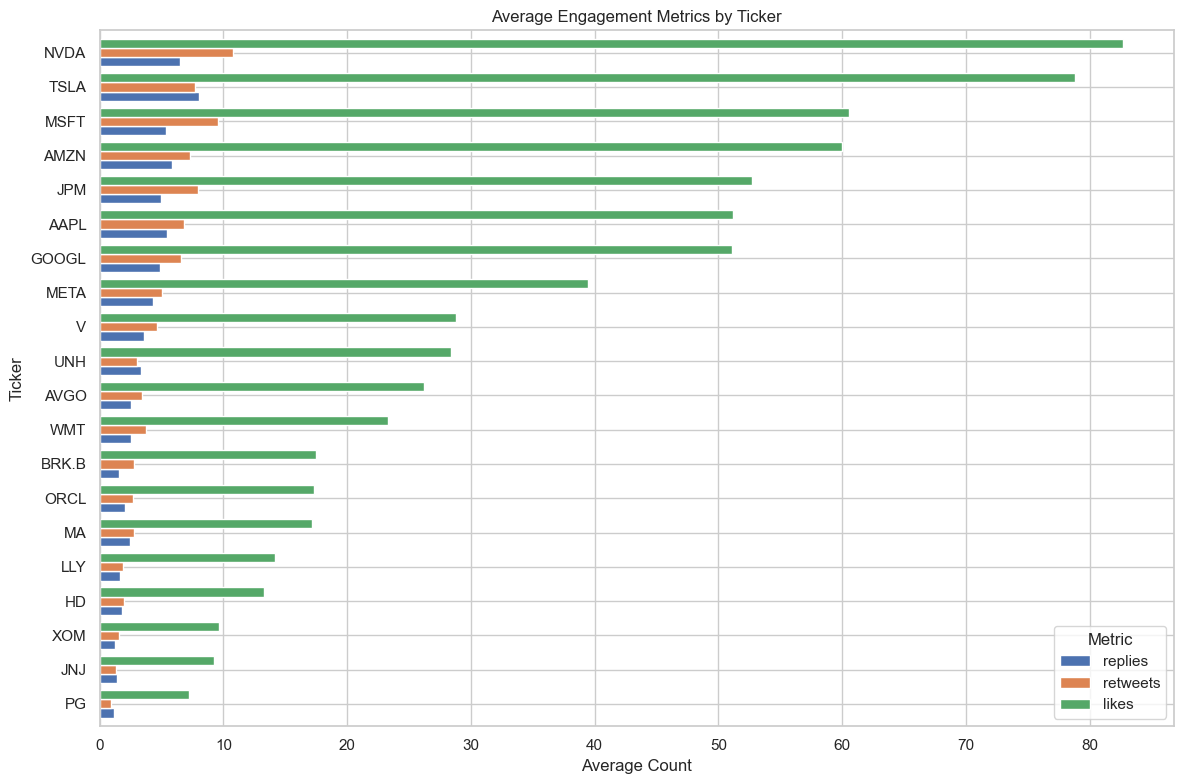

In [11]:
# Average engagement by ticker
engagement_by_ticker = tweets.groupby("ticker")[engagement_cols].mean().sort_values("likes", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
engagement_by_ticker.plot(kind="barh", ax=ax, width=0.8)
ax.set_xlabel("Average Count")
ax.set_ylabel("Ticker")
ax.set_title("Average Engagement Metrics by Ticker")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

In [12]:
# Top 10 most engaged tweets
top_tweets = tweets.nlargest(10, "total_engagement")[["ticker", "body", "likes", "retweets", "replies", "total_engagement", "post_date"]]
print("Top 10 Most Engaged Tweets:")
for idx, row in top_tweets.iterrows():
    print(f"\n[{row['ticker']}] {row['total_engagement']:,} engagement ({row['likes']:,} likes, {row['retweets']:,} RT, {row['replies']:,} replies)")
    print(f"  {row['body'][:150]}..." if len(str(row['body'])) > 150 else f"  {row['body']}")

Top 10 Most Engaged Tweets:

[NVDA] 48,700.0 engagement (42,000.0 likes, 4,900 RT, 1,800 replies)
  BREAKING: This is not a memecoin. This is Nvidia, $NVDA, the most valuable company in the world before today. It is down 17%. It lost $560 billion in ...

[MSFT] 46,100.0 engagement (38,000.0 likes, 6,700 RT, 1,400 replies)
  JUST IN: Microsoft $MSFT terminates Israeli military's access to its technology after uncovering mass civilian surveillance system, violating its term...

[MSFT] 34,700.0 engagement (26,000.0 likes, 7,200 RT, 1,500 replies)
  My 3-minute presentation to the $MSFT Board of Directors and @SatyaNadella , articulating why the company should do the right thing and adopt #Bitcoin...

[MSFT] 34,700.0 engagement (28,000.0 likes, 5,500 RT, 1,200 replies)
  Microsoft, $MSFT, has requested 6,327 H-1B visas, mostly from India, in Washington, per Amanda Goodall. That same month, it laid off 2,300 workers in ...

[NVDA] 33,030.0 engagement (26,000.0 likes, 6,600 RT, 430 replies)


## 6. Tweet Body Length Analysis

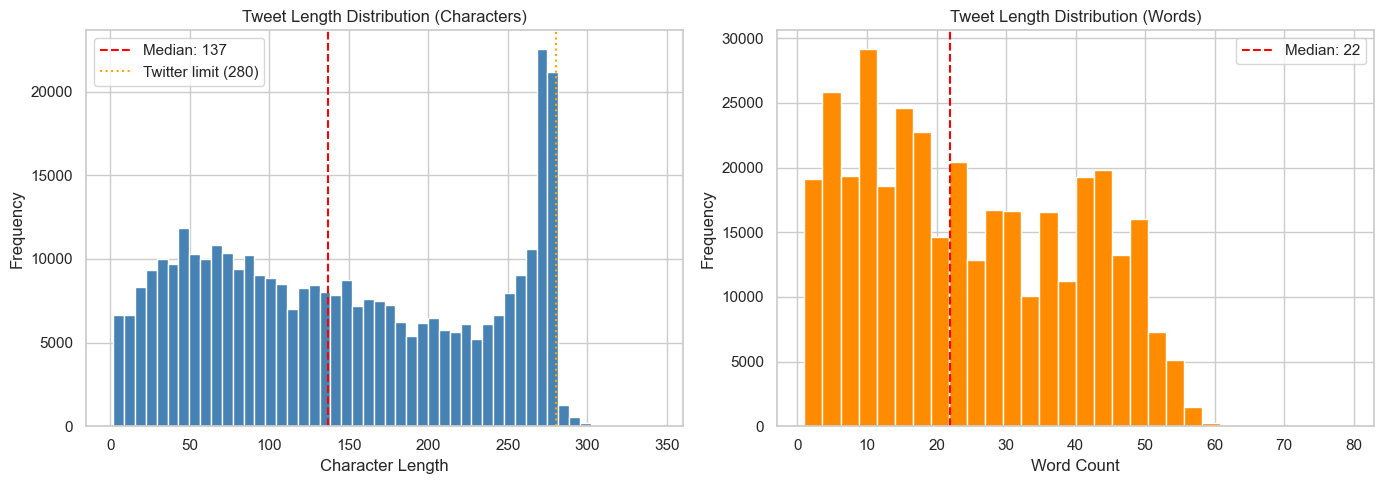

Tweet character length - Mean: 145.3, Median: 137, Std: 86.9
Tweet word count       - Mean: 24.6, Median: 22, Std: 15.3


In [13]:
tweets["body_len"] = tweets["body"].astype(str).str.len()
tweets["body_word_count"] = tweets["body"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tweets["body_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Tweet Length Distribution (Characters)")
axes[0].axvline(tweets["body_len"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_len'].median():.0f}")
axes[0].axvline(280, color="orange", linestyle=":", label="Twitter limit (280)")
axes[0].legend()

axes[1].hist(tweets["body_word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Tweet Length Distribution (Words)")
axes[1].axvline(tweets["body_word_count"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Tweet character length - Mean: {tweets['body_len'].mean():.1f}, Median: {tweets['body_len'].median():.0f}, Std: {tweets['body_len'].std():.1f}")
print(f"Tweet word count       - Mean: {tweets['body_word_count'].mean():.1f}, Median: {tweets['body_word_count'].median():.0f}, Std: {tweets['body_word_count'].std():.1f}")

## 7. Day-of-Week and Hour Distribution

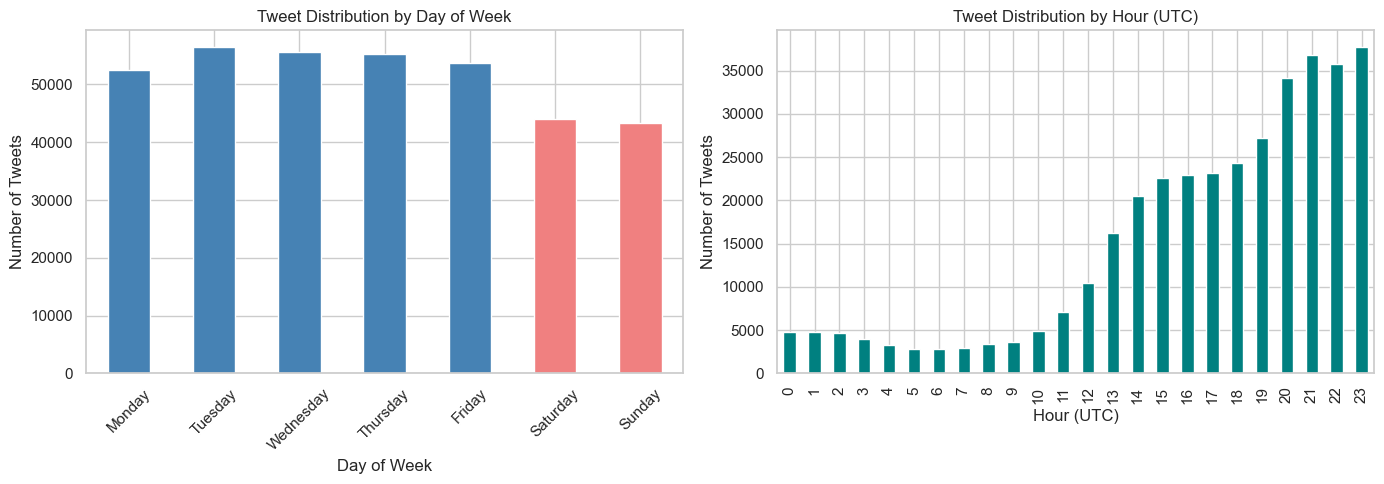

Weekday tweets: 273,576 (75.8%)
Weekend tweets: 87,477 (24.2%)


In [14]:
tweets["day_of_week"] = tweets["post_date"].dt.day_name()
tweets["hour"] = tweets["post_date"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = tweets["day_of_week"].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
dow_counts.plot(kind="bar", ax=axes[0], color=["steelblue"]*5 + ["lightcoral"]*2)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Tweet Distribution by Day of Week")
axes[0].tick_params(axis="x", rotation=45)

# Hour of day
hour_counts = tweets["hour"].value_counts().sort_index()
hour_counts.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Number of Tweets")
axes[1].set_title("Tweet Distribution by Hour (UTC)")

plt.tight_layout()
plt.show()

weekday = dow_counts[:5].sum()
weekend = dow_counts[5:].sum()
print(f"Weekday tweets: {weekday:,} ({weekday/len(tweets)*100:.1f}%)")
print(f"Weekend tweets: {weekend:,} ({weekend/len(tweets)*100:.1f}%)")

## 8. Duplicate and Data Quality Analysis

In [15]:
# Check for duplicate tweet bodies
dup_bodies = tweets["body"].duplicated().sum()
dup_full = tweets.duplicated().sum()

print(f"Duplicate tweet bodies (Same text, different Ticker): {dup_bodies:,} ({dup_bodies/len(tweets)*100:.1f}%)")
print(f"Fully duplicate rows (Summation of duplicates per ticker): {dup_full:,} ({dup_full/len(tweets)*100:.1f}%)")

# Duplicate body counts per ticker (per file)
print("\nDuplicate bodies per ticker:")
dup_per_ticker = tweets.groupby("ticker")["body"].apply(lambda x: x.duplicated().sum())
dup_total_per_ticker = tweets.groupby("ticker").size()
dup_pct = (dup_per_ticker / dup_total_per_ticker * 100).round(2)
dup_df = pd.DataFrame({"Duplicate Bodies": dup_per_ticker, "Total": dup_total_per_ticker, "Duplicate %": dup_pct})
dup_df = dup_df.sort_values("Duplicate Bodies", ascending=False)
display(dup_df)

# Tweets appearing across multiple tickers
body_ticker_count = tweets.groupby("body")["ticker"].nunique()
cross_ticker = body_ticker_count[body_ticker_count > 1]
print(f"\nTweets mentioning multiple tickers: {len(cross_ticker):,}")

if len(cross_ticker) > 0:
    print("\nSample cross-ticker tweets:")
    for body in cross_ticker.sort_values(ascending=False).head(5).index:
        tickers = tweets[tweets["body"] == body]["ticker"].unique()
        print(f"  [{', '.join(tickers)}] {str(body)[:100]}")

Duplicate tweet bodies (Same text, different Ticker): 40,812 (11.3%)
Fully duplicate rows (Summation of duplicates per ticker): 0 (0.0%)

Duplicate bodies per ticker:


,Duplicate Bodies,Total,Duplicate %
ticker,,,
MA,2109,8946,23.57
BRK.B,2100,17635,11.91
XOM,1895,16567,11.44
PG,1629,8922,18.26
TSLA,1542,44855,3.44
JNJ,1530,12106,12.64
UNH,1504,16956,8.87
WMT,1434,12647,11.34
GOOGL,1193,27121,4.40



Tweets mentioning multiple tickers: 14,035

Sample cross-ticker tweets:
  [AAPL, BRK.B, MSFT, NVDA, TSLA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $GOOGL $LLY $AVGO $GOOG $UNH
  [AAPL, BRK.B, JPM, MSFT, TSLA, XOM] 【時価総額上位銘柄トレンド】 $AAPL $MSFT $GOOG $AMZN $TSLA $BRK.B $META $JNJ $T $NVDA $KO $XOM $WMT $PG $JPM $V $M
  [AAPL, AMZN, BRK.B, JPM, MSFT, XOM] What Stocks Do Institutional Investors Own? I give you the Top 25 $MSFT $AAPL $AMZN $NVDA $GOOGL $AV
  [AAPL, BRK.B, JPM, MSFT, NVDA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $LLY $GOOGL $AVGO $GOOG $UNH
  [AAPL, BRK.B, MSFT, NVDA, XOM] Top 25 Stocks Institutional Investors Own $AAPL $MSFT $NVDA $AMZN $META $GOOGL $AVGO $LLY $GOOG $JPM


In [16]:
# Check for empty or very short tweets
empty_tweets = tweets[tweets["body"].isna() | (tweets["body"] == "")]
short_tweets = tweets[tweets["body_len"] < 10]

print(f"Empty tweets: {len(empty_tweets):,}")
print(f"Very short tweets (<10 chars): {len(short_tweets):,}")

if len(short_tweets) > 0:
    print("\nSample short tweets:")
    for _, row in short_tweets.head(5).iterrows():
        print(f"  [{row['ticker']}] '{row['body']}'")

Empty tweets: 0
Very short tweets (<10 chars): 7,324

Sample short tweets:
  [AAPL] '$AAPL'
  [AAPL] '$AAPL'
  [AAPL] '$AAPL'
  [AAPL] '$AAPL 애플'
  [AAPL] '$AAPL'


## 8.5 Language Breakdown

In [17]:
from lingua import LanguageDetectorBuilder

# Build detector for all languages
detector = LanguageDetectorBuilder.from_all_languages().build()

def detect_lang(text):
    try:
        text = str(text).replace("\n", " ").strip()
        if not text or len(text) < 3:
            return "unknown"
        lang = detector.detect_language_of(text)
        return lang.iso_code_639_1.name.lower() if lang else "unknown"
    except:
        return "unknown"

tweets["language"] = tweets["body"].apply(detect_lang)

# Language breakdown
lang_counts = tweets["language"].value_counts()
total = len(tweets)

print(f"Languages detected: {len(lang_counts)}")
print(f"\nTop 10 languages:")
lang_df = pd.DataFrame({
    "Count": lang_counts,
    "%": (lang_counts / total * 100).round(2)
})
display(lang_df.head(10))

# Plot top 10 languages
fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.head(10).plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 10))
ax.set_xlabel("Language")
ax.set_ylabel("Number of Tweets")
ax.set_title("Tweet Language Distribution (Top 10)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# English vs non-English
en_count = lang_counts.get("en", 0)
non_en = total - en_count
print(f"\nEnglish tweets: {en_count:,} ({en_count/total*100:.1f}%)")
print(f"Non-English tweets: {non_en:,} ({non_en/total*100:.1f}%)")

ModuleNotFoundError: No module named 'lingua'

## 9. Engagement vs Tweet Length Correlation

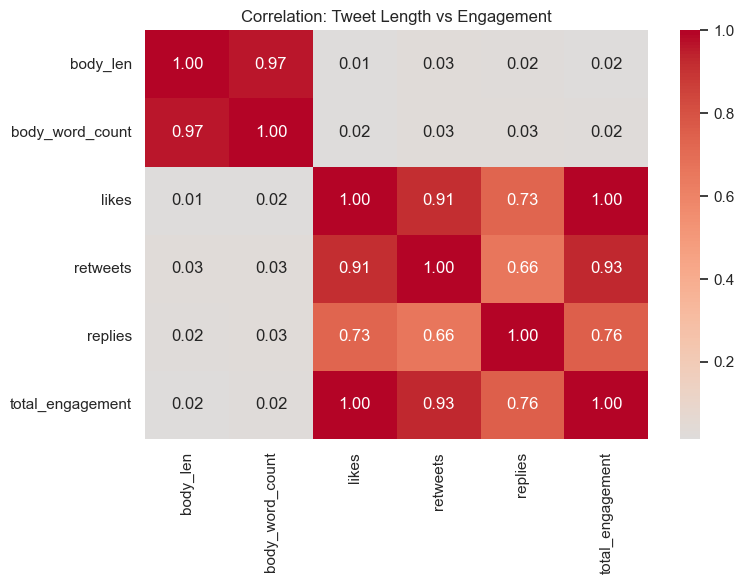

In [ ]:
# Correlation between length and engagement
corr_cols = ["body_len", "body_word_count", "likes", "retweets", "replies", "total_engagement"]
corr_matrix = tweets[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation: Tweet Length vs Engagement")
plt.tight_layout()
plt.show()

## 10. Summary

In [ ]:
print("TWEETS DATASET EDA SUMMARY")
print(f"Total tweets:            {len(tweets):,}")
print(f"Tickers:                 {tweets['ticker'].nunique()}")
print(f"Date range:              {tweets['post_date'].min().strftime('%Y-%m-%d')} to {tweets['post_date'].max().strftime('%Y-%m-%d')}")
print(f"Missing bodies:          {tweets['body'].isna().sum():,}")
print(f"Duplicate rows:          {tweets.duplicated().sum():,}")
print(f"Avg tweet length:        {tweets['body_len'].mean():.0f} chars / {tweets['body_word_count'].mean():.0f} words")
print(f"Avg tweets per day:      {daily_counts.mean():.1f}")
print(f"\nEngagement metrics:")
print(f"Total likes:           {tweets['likes'].sum():,}")
print(f"Total retweets:        {tweets['retweets'].sum():,}")
print(f"Total replies:         {tweets['replies'].sum():,}")
print(f"Avg likes/tweet:       {tweets['likes'].mean():.1f}")
print(f"Avg retweets/tweet:    {tweets['retweets'].mean():.1f}")

TWEETS DATASET EDA SUMMARY
Total tweets:            361,053
Tickers:                 20
Date range:              2023-10-10 to 2025-10-10
Missing bodies:          0
Duplicate rows:          0
Avg tweet length:        145 chars / 25 words
Avg tweets per day:      493.2

Engagement metrics:
Total likes:           15,390,733.0
Total retweets:        1,957,576
Total replies:         1,533,187
Avg likes/tweet:       42.6
Avg retweets/tweet:    5.4
